# Value Profiles & Distributional Pluralism

Converts raw logistic-regression coefficients into softmax-normalised
value priority distributions (π_V = softmax(β / T)) with configurable
temperature *T*, then uses Jensen-Shannon divergence to quantify
within-group diversity for LLMs versus physicians.

In [163]:
DIR = "/Users/payalchandak/Desktop/HVP Preprint/ValueBench"
import os
os.chdir(DIR)

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

from src.analysis import (
    load_all_decisions,
    HUMAN_CONSENSUS,
    value_weights,
    softmax_profile,
    pairwise_jsd_matrix,
    lrt_uniform_null,
    bootstrap_mean_jsd,
    permutation_test_jsd,
)
from src.response_models.case import VALUE_NAMES

from pathlib import Path
LLM_DIR = Path(DIR) / "data" / "llm_decisions" / "physician_recommendation"

MODEL_DISPLAY_NAMES = {
    'anthropic/claude-opus-4.5': 'Claude Opus 4.5',
    'deepseek/deepseek-chat': 'DeepSeek Chat',
    'google/gemini-3-pro-preview': 'Gemini 3 Pro',
    'meta-llama/llama-4-maverick': 'Meta Llama 4 Maverick',
    'mistralai/mistral-large-2512': 'Mistral AI Large',
    'moonshotai/kimi-k2-thinking': 'Moonshot AI Kimi K2',
    'openai/gpt-5.2': 'OpenAI GPT 5.2',
    'perplexity/sonar-pro': 'Perplexity Sonar Pro',
    'qwen/qwen3-max': 'Qwen 3 Max',
    'x-ai/grok-4': 'X-AI Grok 4',
    'baidu/ernie-4.5-vl-424b-a47b': 'Baidu Ernie 4.5 VL',
    'z-ai/glm-4.6': 'Zhipu AI GLM 4.6',
    'human_consensus': 'Physician Consensus',
}

def get_display_name(model_id):
    if model_id in MODEL_DISPLAY_NAMES:
        return MODEL_DISPLAY_NAMES[model_id]
    if model_id.startswith("human/"):
        return "Physician " + model_id.split("/")[-1].split("_")[1][:4].upper()
    return model_id.split("/")[-1]

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.family"] = "sans-serif"

all_decisions = load_all_decisions(llm_dir=LLM_DIR)
decisions = [r for r in all_decisions if any(m.startswith("human/") for m in r.models)]

llm_models = sorted({m for r in decisions for m in r.models if not m.startswith("human/")})
human_participants = sorted({m for r in decisions for m in r.models if m.startswith("human/")})
all_decision_makers = llm_models + [HUMAN_CONSENSUS] + human_participants

print(f"Cases: {len(decisions)}")
print(f"LLMs: {len(llm_models)}  |  Human participants: {len(human_participants)}  |  Total decision makers: {len(all_decision_makers)}")

Cases: 50
LLMs: 12  |  Human participants: 20  |  Total decision makers: 33


In [164]:
TEMPERATURE = 0.25

## 1. Fit value weight profiles

Point-estimate logistic regression for every decision maker.

In [165]:
vw_results = {}
for model in all_decision_makers:
    try:
        vw_results[model] = value_weights(decisions, model)
    except ValueError as exc:
        print(f"  skip {get_display_name(model)}: {exc}")

print(f"Fitted {len(vw_results)} / {len(all_decision_makers)} decision makers")

Fitted 33 / 33 decision makers


## 2. Goodness of fit — McFadden pseudo-R²

Higher R² means the four-value model explains more of the
decision maker's choice variance than a null (intercept-free) model.

In [166]:
gof_rows = []
for model, res in vw_results.items():
    row = {"Decision Maker": get_display_name(model)}
    if res.glm_result is not None:
        try:
            row["McFadden R²"] = res.glm_result.pseudo_rsquared(kind="mcf")
        except Exception:
            row["McFadden R²"] = np.nan
        row["Deviance"] = res.glm_result.deviance
        row["Log-Lik"] = res.glm_result.llf
    else:
        row["McFadden R²"] = np.nan
        row["Deviance"] = np.nan
        row["Log-Lik"] = np.nan
    gof_rows.append(row)

gof_df = pd.DataFrame(gof_rows).sort_values("McFadden R²", ascending=False).reset_index(drop=True)
gof_df.style.format({"McFadden R²": "{:.4f}", "Deviance": "{:.2f}", "Log-Lik": "{:.2f}"}).background_gradient(
    subset=["McFadden R²"], cmap="YlGn"
)

,Decision Maker,McFadden R²,Deviance,Log-Lik
0,Mistral AI Large,0.3296,398.47,-224.49
1,Moonshot AI Kimi K2,0.3079,323.49,-220.57
2,Physician 0EFA,0.2631,51.02,-25.51
3,Qwen 3 Max,0.2605,414.75,-229.93
4,X-AI Grok 4,0.2574,383.74,-240.53
5,Baidu Ernie 4.5 VL,0.2573,328.39,-232.83
6,Gemini 3 Pro,0.2387,443.43,-251.80
7,Physician AAFB,0.2207,51.75,-25.88
8,Zhipu AI GLM 4.6,0.2155,286.31,-233.66
9,Physician D59B,0.2130,43.37,-21.69


## 3. Softmax normalisation

Transform raw β coefficients into a probability distribution π_V
over the four values using softmax(β / T).

In [167]:
profiles = {}
for model, res in vw_results.items():
    profiles[model] = softmax_profile(res.coefficients, temperature=TEMPERATURE)

profile_rows = []
for model, pi in profiles.items():
    row = {"Decision Maker": get_display_name(model)}
    row.update({v.capitalize(): f"{pi[v]:.3f}" for v in VALUE_NAMES})
    profile_rows.append(row)

profile_df = pd.DataFrame(profile_rows)
profile_df.sort_values(by="Autonomy", ascending=False)

,Decision Maker,Autonomy,Beneficence,Nonmaleficence,Justice
25,Physician AAFB,0.831,0.075,0.045,0.049
15,Physician 0EFA,0.809,0.052,0.128,0.011
26,Physician CB5D,0.683,0.164,0.038,0.115
23,Physician 88AB,0.646,0.156,0.083,0.114
29,Physician DE6E,0.597,0.199,0.064,0.140
16,Physician 14C4,0.551,0.257,0.159,0.034
30,Physician E3BF,0.518,0.158,0.283,0.041
18,Physician 43E7,0.482,0.278,0.176,0.064
12,Physician Consensus,0.453,0.293,0.127,0.127
14,Physician 0D4F,0.359,0.182,0.263,0.196


## 4. Radar charts — softmax(β / T) value profiles

Each subplot shows one decision maker's π_V distribution.
A uniform decision maker would trace a circle at 0.25.

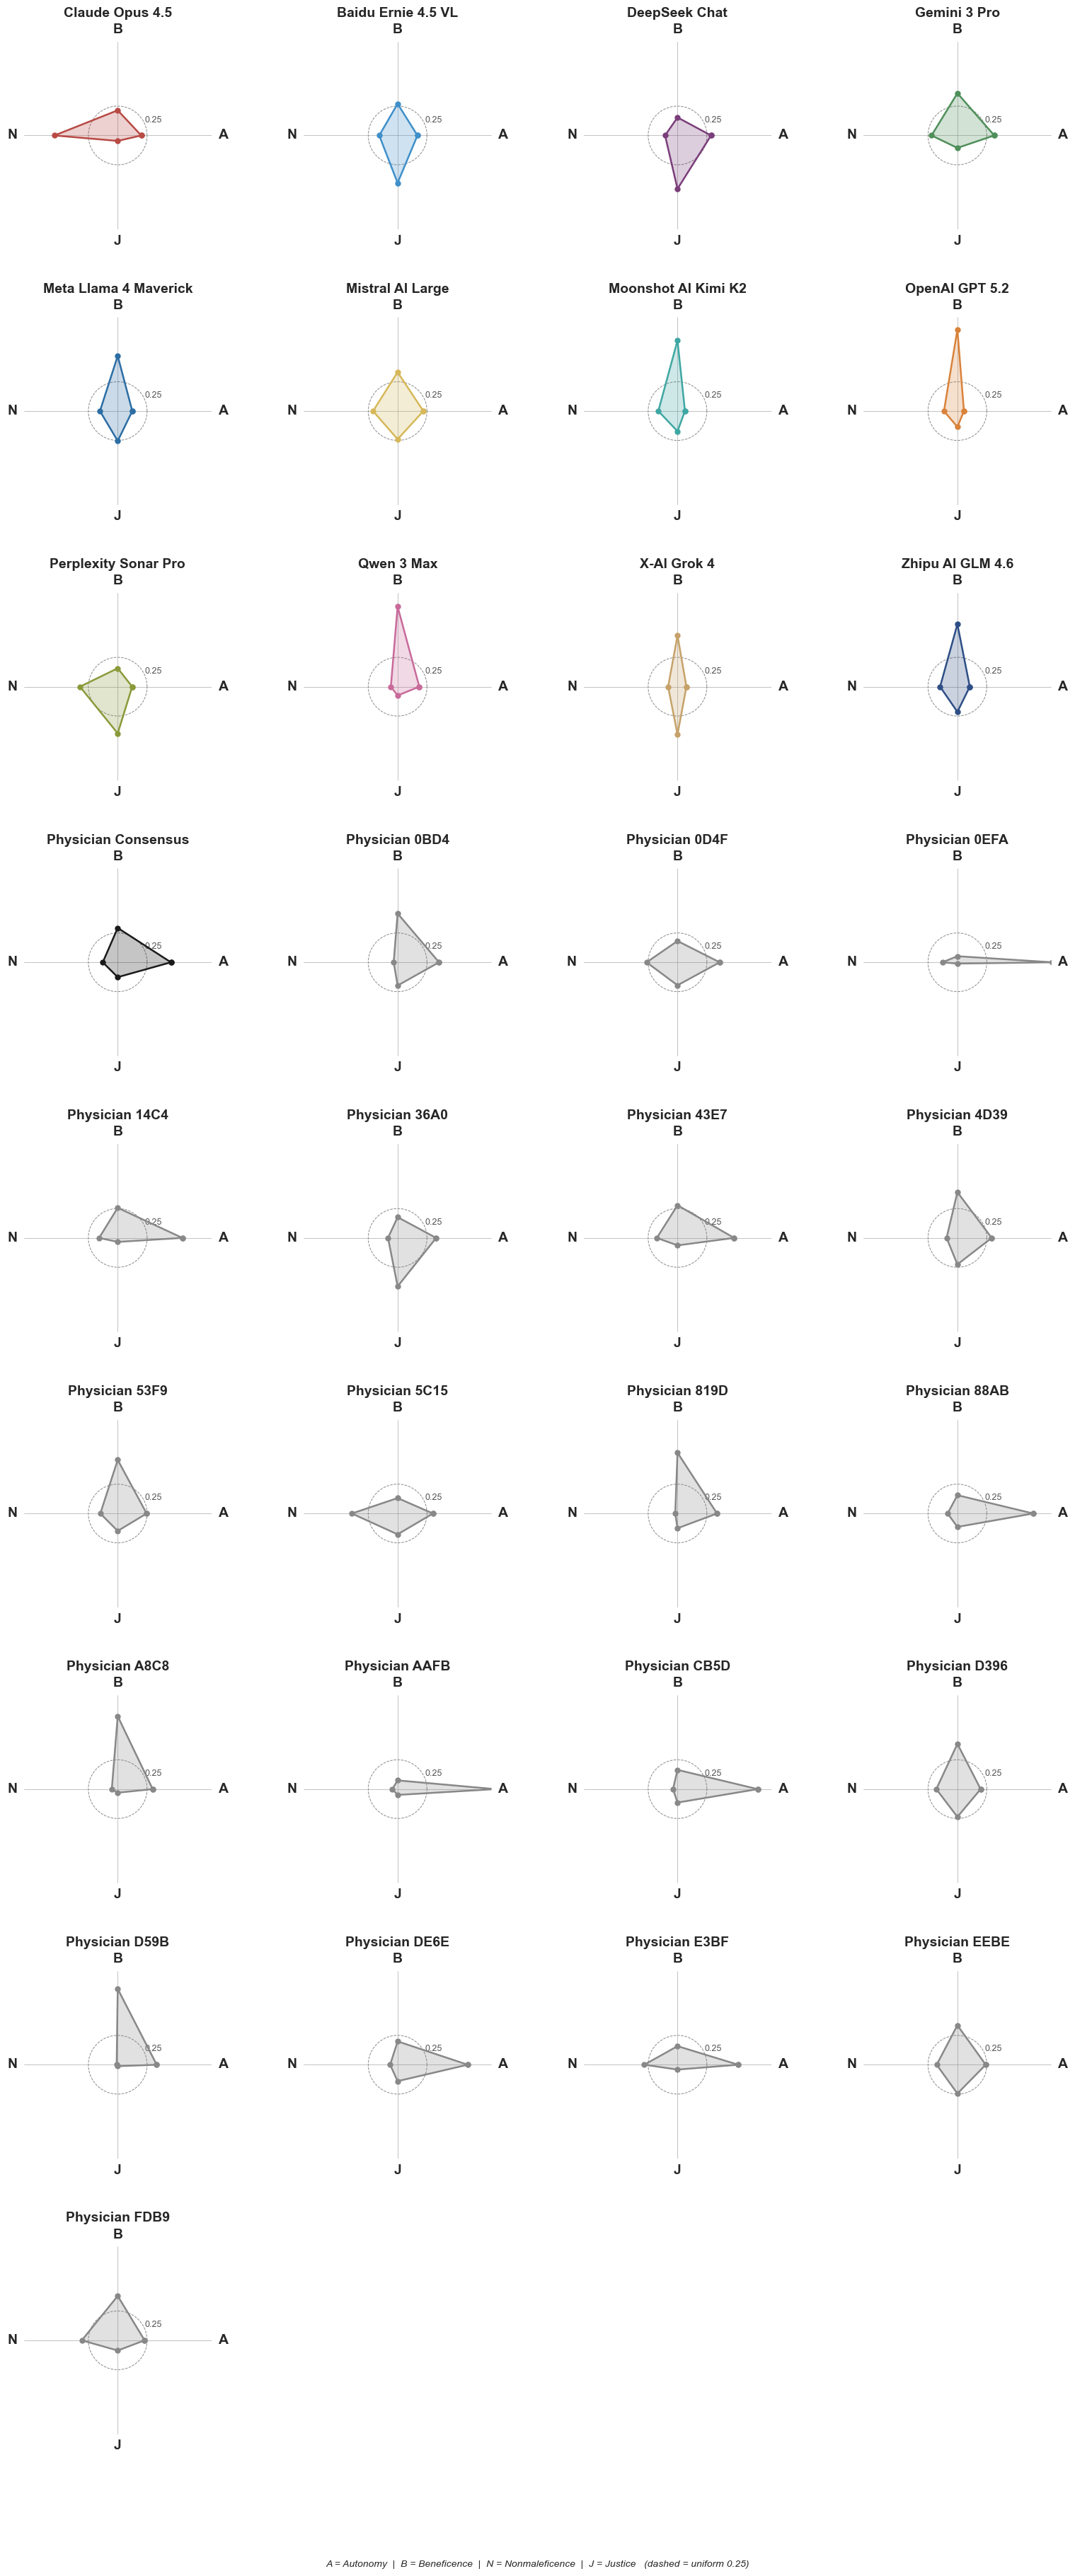

In [168]:
values_cap = [v.capitalize() for v in VALUE_NAMES]
num_vars = len(values_cap)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]

llm_color_palette = [
    "#B84A44", "#3F8FC9", "#7A3E7A", "#4F8F5A",
    "#2C6DA4", "#D6B85A", "#3FA7A3", "#D9823B",
    "#8A9A3A", "#C86A9A", "#C6A26A", "#2E4E86",
]
human_consensus_color = "#1a1a1a"
human_participant_grey = "#888888"

def _color_for(model):
    if model == HUMAN_CONSENSUS:
        return human_consensus_color
    if model.startswith("human/"):
        return human_participant_grey
    idx = llm_models.index(model) if model in llm_models else 0
    return llm_color_palette[idx % len(llm_color_palette)]

models_to_plot = llm_models + [HUMAN_CONSENSUS] + human_participants
n = len(models_to_plot)
n_cols = 4
n_rows = (n + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows),
                         subplot_kw=dict(polar=True))
axes = np.atleast_2d(axes).flatten()
theta_circle = np.linspace(0, 2 * np.pi, 100)
short_labels = ["A", "B", "N", "J"]

for i, model in enumerate(models_to_plot):
    ax = axes[i]
    pi = profiles[model]
    vals = [pi[v] for v in VALUE_NAMES] + [pi[VALUE_NAMES[0]]]
    color = _color_for(model)

    ax.set_ylim(0, .8)
    ax.set_yticks([0.25])
    ax.set_yticklabels(["0.25"], fontsize=9, color="#555555")
    ax.yaxis.grid(False)
    ax.xaxis.grid(True, color="#aaaaaa", linewidth=0.5)

    ax.plot(theta_circle, [0.25] * 100, color="#888888", lw=0.7, ls="--", zorder=1)

    ax.plot(angles, vals, marker="o", markersize=5, lw=1.8, color=color, zorder=3)
    ax.fill(angles, vals, alpha=0.25, color=color, zorder=2)

    ax.set_thetagrids(np.degrees(angles[:-1]), [""] * num_vars)
    for angle, label in zip(angles[:-1], short_labels):
        ax.text(angle, .9, label, fontsize=14, ha="center", va="center", fontweight="bold")

    ax.spines["polar"].set_visible(False)
    ax.set_title(get_display_name(model), fontsize=14, fontweight="bold", pad=25)

for j in range(n, len(axes)):
    axes[j].set_visible(False)

fig.text(0.5, -0.01,
         "A = Autonomy  |  B = Beneficence  |  N = Nonmaleficence  |  J = Justice   (dashed = uniform 0.25)",
         ha="center", fontsize=10, style="italic")
plt.tight_layout(rect=[0, 0.03, 1, 1], h_pad=3.0)
plt.show()

## 5. Likelihood-ratio test for non-uniform prioritisation

H₀: the decision maker weighs all four values equally (uniform prior).
Rejecting H₀ (p < 0.05) means the profile is significantly non-uniform.

In [169]:
lrt_rows = []
for model in all_decision_makers:
    try:
        res = lrt_uniform_null(decisions, model)
        lrt_rows.append({
            "Decision Maker": get_display_name(model),
            "LRT χ²": res["lrt_statistic"],
            "p-value": res["p_value"],
            "df": res["df"],
            "Reject H₀ (α=.05)": res["p_value"] < 0.05,
        })
    except Exception as exc:
        print(f"  skip {get_display_name(model)}: {exc}")

lrt_df = pd.DataFrame(lrt_rows).sort_values("LRT χ²", ascending=False).reset_index(drop=True)

n_reject = lrt_df["Reject H₀ (α=.05)"].sum()
print(f"{n_reject} / {len(lrt_df)} decision makers reject the uniform null at α = 0.05\n")

lrt_df.style.format({"LRT χ²": "{:.2f}", "p-value": "{:.4f}"}).map(
    lambda v: "background-color: #d4edda" if v is True else "",
    subset=["Reject H₀ (α=.05)"],
)

21 / 33 decision makers reject the uniform null at α = 0.05



,Decision Maker,LRT χ²,p-value,df,Reject H₀ (α=.05)
0,Physician Consensus,76.74,0.0000,3,True
1,OpenAI GPT 5.2,65.71,0.0000,3,True
2,Qwen 3 Max,60.55,0.0000,3,True
3,X-AI Grok 4,43.19,0.0000,3,True
4,Moonshot AI Kimi K2,42.40,0.0000,3,True
5,Claude Opus 4.5,40.16,0.0000,3,True
6,Zhipu AI GLM 4.6,27.38,0.0000,3,True
7,Perplexity Sonar Pro,24.72,0.0000,3,True
8,Meta Llama 4 Maverick,23.40,0.0000,3,True
9,Physician D59B,22.30,0.0001,3,True


## 6. Pairwise Jensen-Shannon divergence matrix

JSD (divergence, not distance) between softmax(β / T) profiles.
Darker = more divergent value priorities.

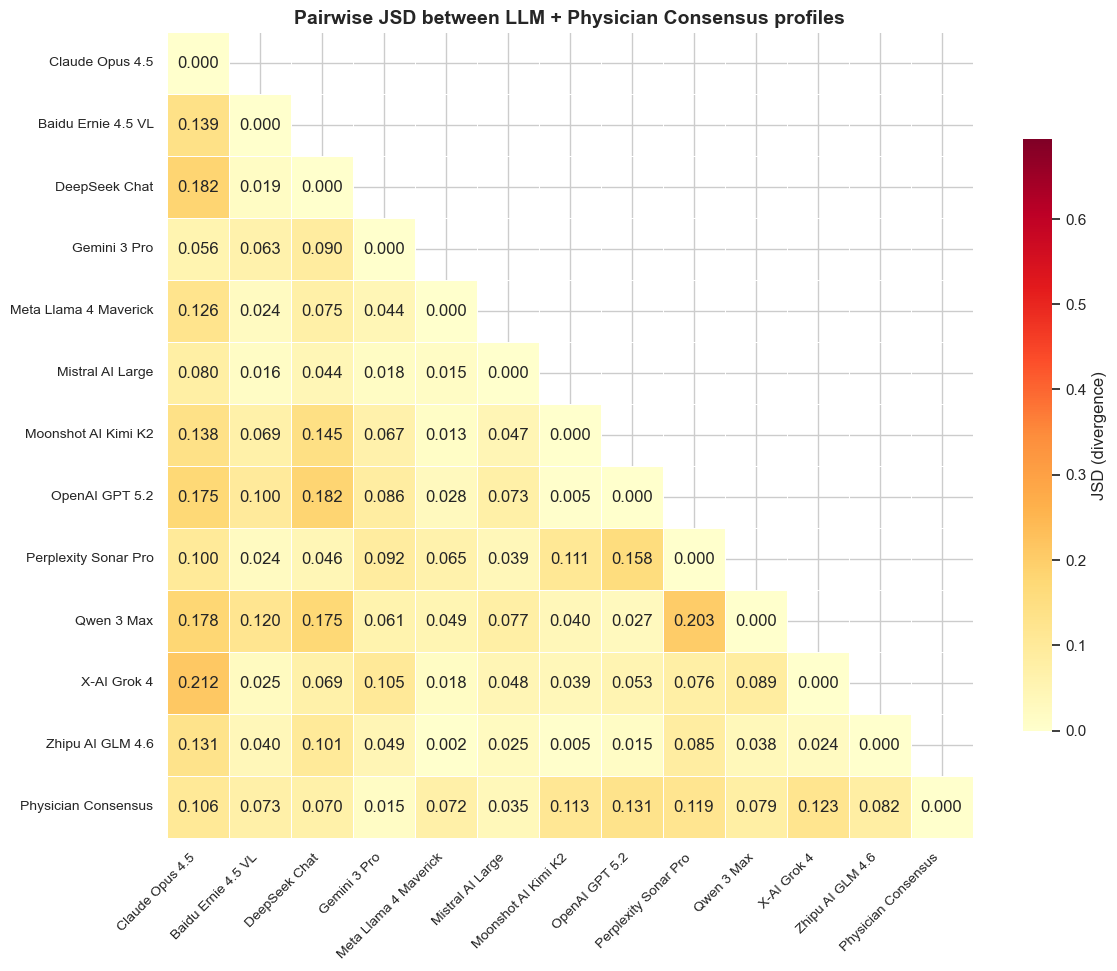

In [170]:
models_for_jsd = llm_models + [HUMAN_CONSENSUS]
jsd_profiles = {m: profiles[m] for m in models_for_jsd}
jsd_mat = pairwise_jsd_matrix(jsd_profiles)

jsd_display = jsd_mat.copy()
jsd_display.index = [get_display_name(m) for m in jsd_display.index]
jsd_display.columns = [get_display_name(m) for m in jsd_display.columns]

mask = np.triu(np.ones_like(jsd_display, dtype=bool), k=1)

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(
    jsd_display,
    mask=mask,
    annot=True, fmt=".3f",
    cmap="YlOrRd",
    linewidths=0.5,
    square=True,
    vmin=0, vmax=np.log(2),
    cbar_kws={"label": "JSD (divergence)", "shrink": 0.7},
    ax=ax,
)
ax.set_title("Pairwise JSD between LLM + Physician Consensus profiles", fontsize=14, fontweight="bold")
plt.xticks(rotation=45, ha="right", fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

## 7. Distributional pluralism — within-group JSD

Compares how diverse value profiles are *within* LLMs versus
*within* physicians (individual participants). Higher mean JSD
implies greater value pluralism.

  LLMs                  mean = 0.0686   95% CI [0.0384, 0.0990]
  Physicians            mean = 0.0804   95% CI [0.0588, 0.1023]
  Δ (LLM − Phys)        mean = -0.0118   95% CI [-0.0492, 0.0252]


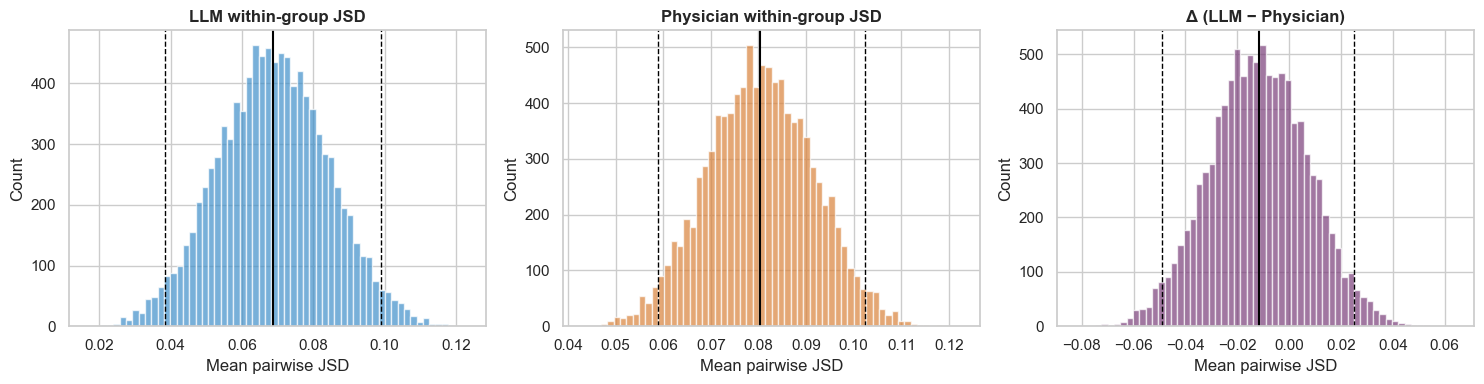

In [171]:
physician_profiles = {m: profiles[m] for m in human_participants if m in profiles}
llm_profiles = {m: profiles[m] for m in llm_models if m in profiles}

all_profiles_for_boot = {**llm_profiles, **physician_profiles}
llm_ids = list(llm_profiles.keys())
physician_ids = list(physician_profiles.keys())

boot = bootstrap_mean_jsd(
    all_profiles_for_boot,
    group_a_ids=llm_ids,
    group_b_ids=physician_ids,
    n_bootstrap=10_000,
    seed=42,
)

for label, key in [("LLMs", "group_a_mean"), ("Physicians", "group_b_mean"), ("Δ (LLM − Phys)", "difference")]:
    br = boot[key]
    lo, hi = br.ci(95)
    print(f"  {label:20s}  mean = {br.mean:.4f}   95% CI [{lo:.4f}, {hi:.4f}]")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
titles = ["LLM within-group JSD", "Physician within-group JSD", "Δ (LLM − Physician)"]
keys = ["group_a_mean", "group_b_mean", "difference"]
colors = ["#3F8FC9", "#D9823B", "#7A3E7A"]

for ax, title, key, color in zip(axes, titles, keys, colors):
    br = boot[key]
    lo, hi = br.ci(95)
    ax.hist(br.samples, bins=60, color=color, alpha=0.7, edgecolor="white")
    ax.axvline(br.mean, color="black", lw=1.5, ls="-")
    ax.axvline(lo, color="black", lw=1, ls="--")
    ax.axvline(hi, color="black", lw=1, ls="--")
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_xlabel("Mean pairwise JSD")
    ax.set_ylabel("Count")

plt.tight_layout()
plt.show()

## 8. Permutation test — are LLMs and physicians equally diverse?

H₀: the mean within-group JSD is the same for both populations.
Test statistic: |mean\_jsd(LLMs) − mean\_jsd(Physicians)|.

Observed |Δ|  = 0.0098
p-value       = 0.7102


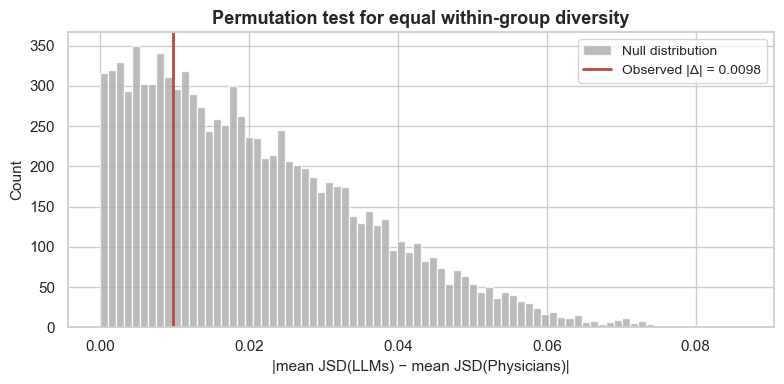


→ Cannot reject H₀ at α = 0.05: no significant difference in within-group diversity.


In [172]:
perm = permutation_test_jsd(
    all_profiles_for_boot,
    group_a_ids=llm_ids,
    group_b_ids=physician_ids,
    n_permutations=10_000,
    seed=42,
)

print(f"Observed |Δ|  = {perm['observed_diff']:.4f}")
print(f"p-value       = {perm['p_value']:.4f}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(perm["null_distribution"], bins=80, color="#aaaaaa", edgecolor="white", alpha=0.8, label="Null distribution")
ax.axvline(perm["observed_diff"], color="#B84A44", lw=2, ls="-", label=f"Observed |Δ| = {perm['observed_diff']:.4f}")
ax.set_xlabel("|mean JSD(LLMs) − mean JSD(Physicians)|", fontsize=11)
ax.set_ylabel("Count", fontsize=11)
ax.set_title("Permutation test for equal within-group diversity", fontsize=13, fontweight="bold")
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

if perm["p_value"] < 0.05:
    print(f"\n→ Reject H₀ at α = 0.05: the two groups differ significantly in value diversity.")
else:
    print(f"\n→ Cannot reject H₀ at α = 0.05: no significant difference in within-group diversity.")

## 9. Per-value distributional tests — LLMs vs Physicians

For each ethical value independently, test whether the softmax(β / T) weight
(π) differs in distribution between LLMs and physicians using both
a **Mann-Whitney U test** and a **permutation test** on the difference
in group means.

In [173]:
from scipy.stats import mannwhitneyu

value_display = {
    "autonomy": "Autonomy", "beneficence": "Beneficence",
    "nonmaleficence": "Nonmaleficence", "justice": "Justice",
}

llm_pi = {v: np.array([llm_profiles[m][v] for m in llm_ids]) for v in VALUE_NAMES}
phys_pi = {v: np.array([physician_profiles[m][v] for m in physician_ids]) for v in VALUE_NAMES}

n_perm = 10_000
rng_perm = np.random.default_rng(42)
per_value_rows = []

for v in VALUE_NAMES:
    x_llm, x_phys = llm_pi[v], phys_pi[v]

    u_stat, p_mw = mannwhitneyu(x_llm, x_phys, alternative="two-sided")

    obs_diff = float(x_llm.mean() - x_phys.mean())
    pooled = np.concatenate([x_llm, x_phys])
    n_l = len(x_llm)
    null = np.empty(n_perm)
    for i in range(n_perm):
        p = rng_perm.permutation(pooled)
        null[i] = p[:n_l].mean() - p[n_l:].mean()
    p_perm = float(np.mean(np.abs(null) >= np.abs(obs_diff)))

    per_value_rows.append({
        "Value": value_display[v],
        "LLM mean π": round(x_llm.mean(), 4),
        "Physician mean π": round(x_phys.mean(), 4),
        "Δ (LLM − Phys)": round(obs_diff, 4),
        "Mann-Whitney U": round(u_stat, 1),
        "MW p-value": round(p_mw, 4),
        "Perm p-value": round(p_perm, 4),
    })

per_value_df = pd.DataFrame(per_value_rows)

alpha = 0.05
n_tests = len(VALUE_NAMES)
bonferroni_alpha = alpha / n_tests

def _highlight_sig(val):
    try:
        v = float(val)
        if v < bonferroni_alpha:
            return "font-weight: bold; color: #B84A44"
        elif v < alpha:
            return "color: #D9823B"
    except (ValueError, TypeError):
        pass
    return ""

print(f"Significance thresholds:  α = {alpha}  |  Bonferroni-corrected α = {bonferroni_alpha}")
per_value_df.style.map(_highlight_sig, subset=["MW p-value", "Perm p-value"]).hide(axis="index")

Significance thresholds:  α = 0.05  |  Bonferroni-corrected α = 0.0125


Value,LLM mean π,Physician mean π,Δ (LLM − Phys),Mann-Whitney U,MW p-value,Perm p-value
Autonomy,0.160100,0.431600,-0.271500,13.000000,0.000000,0.000100
Beneficence,0.408700,0.298900,0.109800,158.000000,0.144400,0.104300
Nonmaleficence,0.188900,0.136300,0.052600,152.000000,0.220100,0.222200
Justice,0.242400,0.133300,0.109100,174.000000,0.037300,0.016300


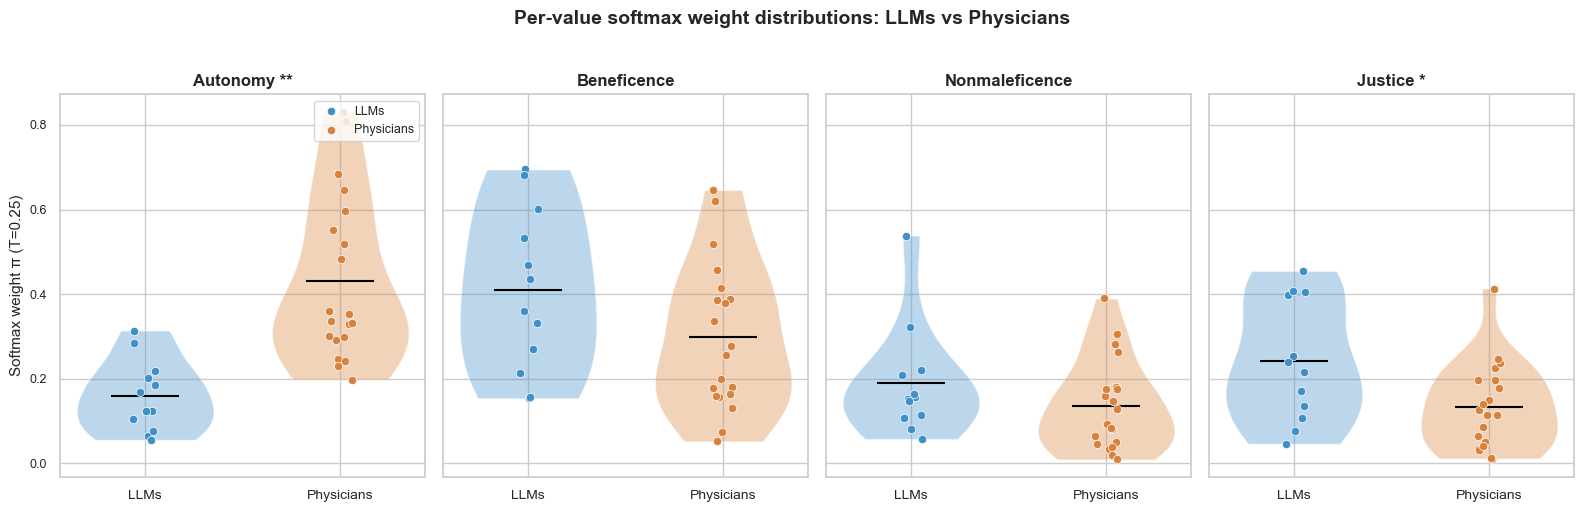


Interpretation (* p < 0.05, ** p < Bonferroni-corrected α):

  ** Autonomy: significant after Bonferroni correction (MW p=0.0000, Perm p=0.0001)
     Beneficence: no significant difference (MW p=0.1444, Perm p=0.1043)
     Nonmaleficence: no significant difference (MW p=0.2201, Perm p=0.2222)
   * Justice: nominally significant (MW p=0.0373, Perm p=0.0163)


In [174]:
fig, axes = plt.subplots(1, 4, figsize=(16, 5), sharey=True)
rng_jit = np.random.default_rng(0)
group_colors = ["#3F8FC9", "#D9823B"]

for idx, v in enumerate(VALUE_NAMES):
    ax = axes[idx]
    x_llm, x_phys = llm_pi[v], phys_pi[v]

    parts = ax.violinplot(
        [x_llm, x_phys], positions=[0, 1],
        showmeans=True, showextrema=False, widths=0.7,
    )
    for pc, c in zip(parts["bodies"], group_colors):
        pc.set_facecolor(c)
        pc.set_alpha(0.35)
    parts["cmeans"].set_color("black")
    parts["cmeans"].set_linewidth(1.5)

    jitter = 0.06
    ax.scatter(
        rng_jit.uniform(-jitter, jitter, len(x_llm)), x_llm,
        c=group_colors[0], s=36, zorder=5,
        edgecolors="white", linewidths=0.5, label="LLMs",
    )
    ax.scatter(
        1 + rng_jit.uniform(-jitter, jitter, len(x_phys)), x_phys,
        c=group_colors[1], s=36, zorder=5,
        edgecolors="white", linewidths=0.5, label="Physicians",
    )

    row = per_value_rows[idx]
    sig = ""
    if row["MW p-value"] < bonferroni_alpha or row["Perm p-value"] < bonferroni_alpha:
        sig = " **"
    elif row["MW p-value"] < alpha or row["Perm p-value"] < alpha:
        sig = " *"

    ax.set_title(f"{value_display[v]}{sig}", fontsize=12, fontweight="bold")
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["LLMs", "Physicians"], fontsize=10)
    if idx == 0:
        ax.set_ylabel(f"Softmax weight π (T={TEMPERATURE})", fontsize=11)
    ax.tick_params(axis="y", labelsize=9)

axes[0].legend(fontsize=9, loc="upper right")
plt.suptitle(
    "Per-value softmax weight distributions: LLMs vs Physicians",
    fontsize=14, fontweight="bold", y=1.02,
)
plt.tight_layout()
plt.show()

print("\nInterpretation (* p < 0.05, ** p < Bonferroni-corrected α):\n")
for r in per_value_rows:
    mw_p, pm_p = r["MW p-value"], r["Perm p-value"]
    name = r["Value"]
    if mw_p < bonferroni_alpha or pm_p < bonferroni_alpha:
        print(f"  ** {name}: significant after Bonferroni correction "
              f"(MW p={mw_p:.4f}, Perm p={pm_p:.4f})")
    elif mw_p < alpha or pm_p < alpha:
        print(f"   * {name}: nominally significant "
              f"(MW p={mw_p:.4f}, Perm p={pm_p:.4f})")
    else:
        print(f"     {name}: no significant difference "
              f"(MW p={mw_p:.4f}, Perm p={pm_p:.4f})")